In [6]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb


In [7]:
# Carica i dati
data = load_iris()

# Converti in DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Aggiungi la colonna target
df["target"] = data.target

X = df.drop("target", axis=1)
y = df["target"]


In [8]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [12]:
df.drop_duplicates(inplace=True)

Distribuzione delle varibili con scatterplot

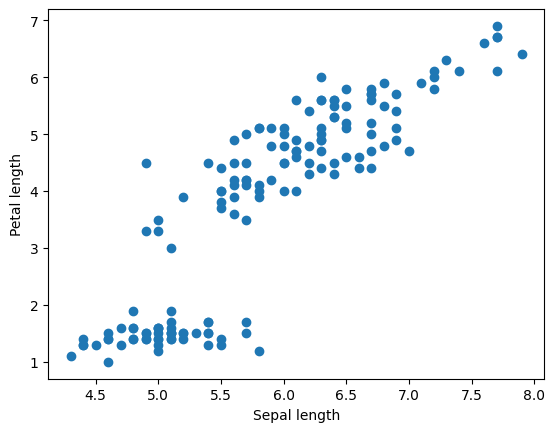

In [13]:
plt.scatter(df["sepal length (cm)"], df["petal length (cm)"])
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.show()

Pairplot

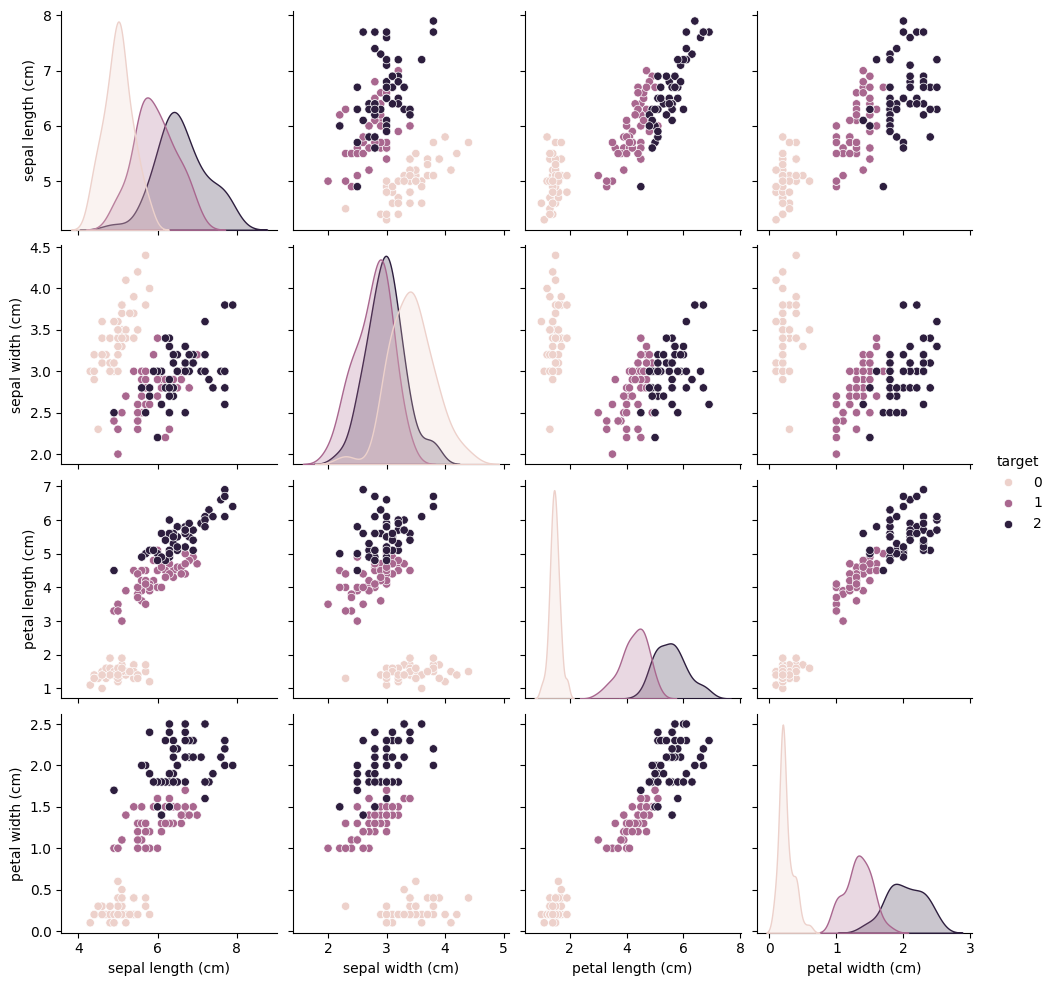

In [14]:
sns.pairplot(df, hue="target")
plt.show()

Correlazione

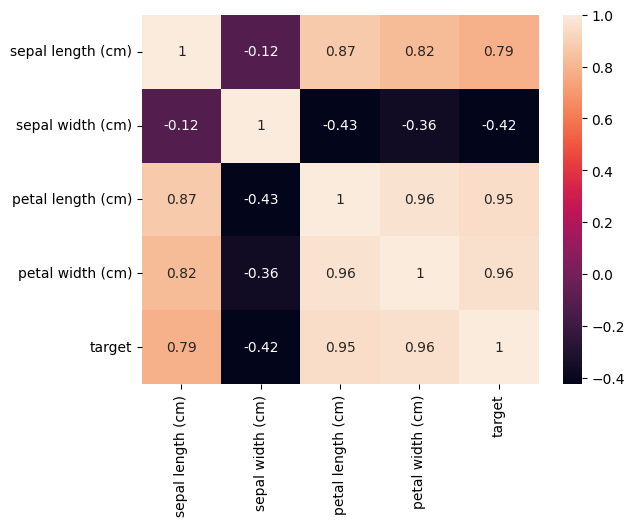

In [15]:
df.corr()
sns.heatmap(df.corr(), annot=True)
plt.show()

In [16]:
#xgboost model
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.1,
    max_depth=4,
    n_estimators=100,
)

model.fit(X_train, y_train)

#predizione e accurratezza

pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


FEATURE IMPORTANCE

grafico a barre che mostra quanto ogni caratteristica (feature) del dataset ha contribuito alla decisione del modello.

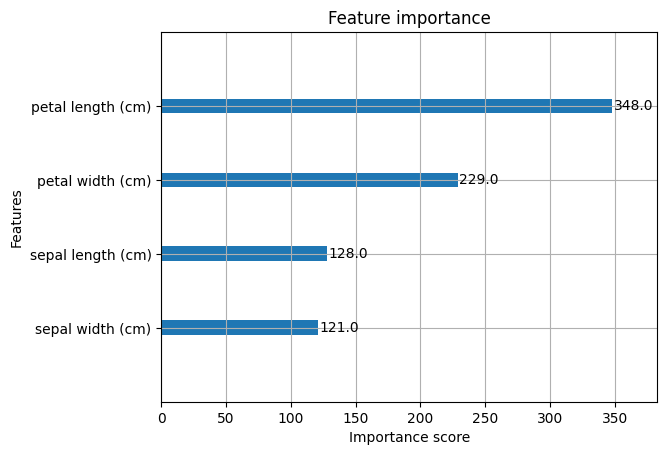

In [17]:
xgb.plot_importance(model)
plt.show()